In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve

In [3]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
from sklearn.linear_model import LogisticRegression

### Load Dataset

In [7]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Data Exploration (EDA)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Histograms

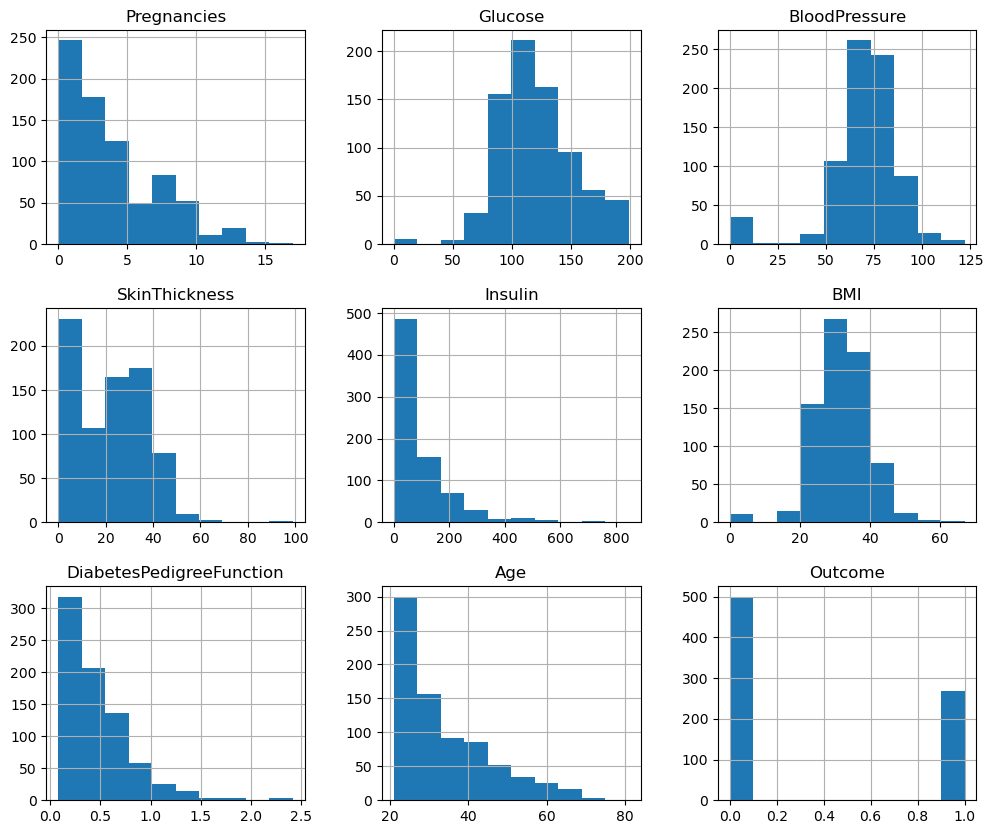

In [11]:
df.hist(figsize=(12,10))
plt.show()

### Boxplot

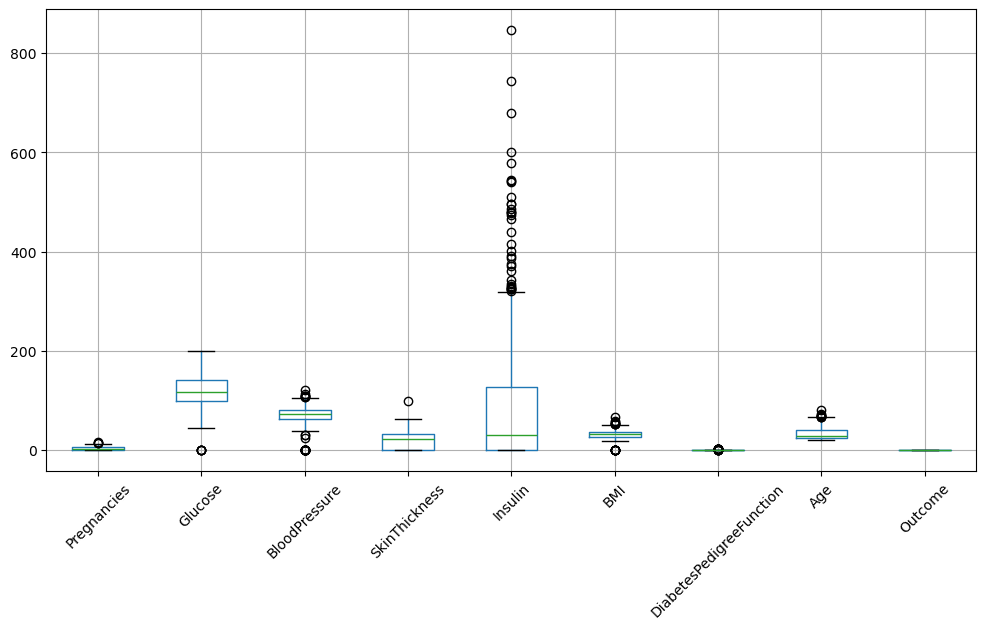

In [12]:
plt.figure(figsize=(12, 6))
df.boxplot(rot=45)
plt.show()

### Correlation Heatmap

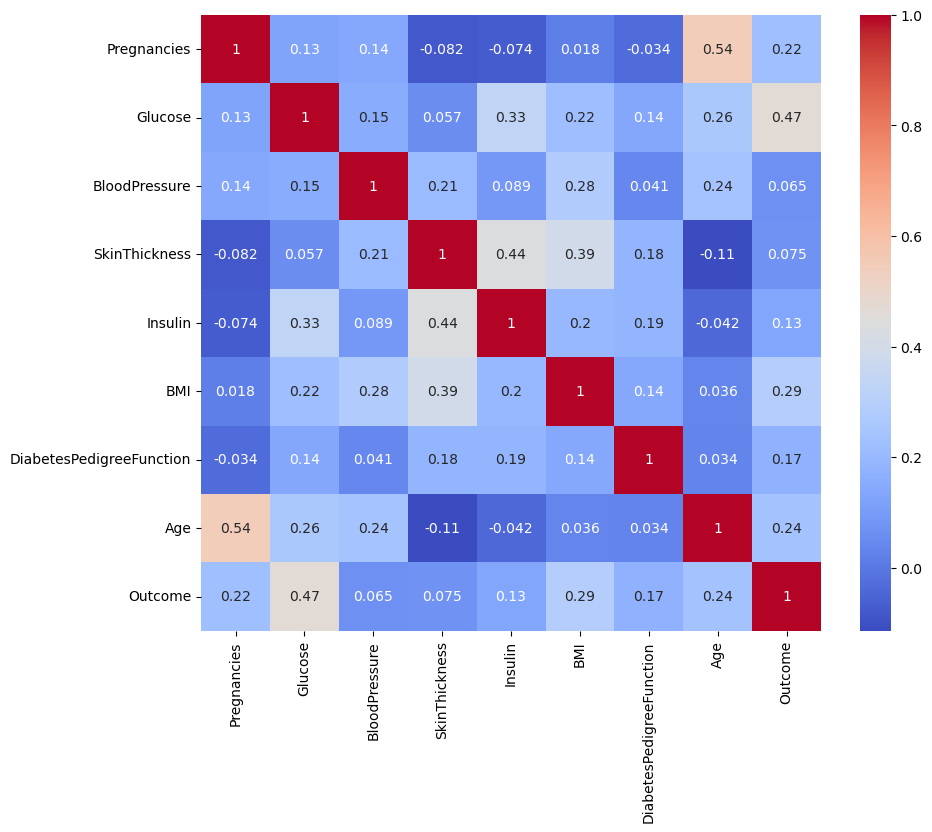

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Handle Missing values

In [14]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

### Features and Target

In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression Model

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Prediction

In [18]:
y_pred = model.predict(X_test)

### Accuracy

In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.7532467532467533


### Precision

In [20]:
print("Precision :",precision_score(y_test, y_pred))

Precision : 0.6666666666666666


### Recall

In [21]:
print("Recall :",recall_score(y_test, y_pred))

Recall : 0.6181818181818182


### F1 Score

In [22]:
print("F1 Score :",f1_score(y_test, y_pred))

F1 Score : 0.6415094339622641


### ROC-AUC Score

In [23]:
def plot_roc(y, y_prob):
    fpr, tpr, thresh = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    print("ROC - AUC Score:", auc)

    plt.figure(figsize=(5,5))
    plt.title("ROC Curve", fontsize=15)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1],[0, 1], 'r--', label="Random Classifier")

    plt.legend(loc="lower right")
    plt.show()

ROC - AUC Score: 0.8211202938475666
ROC - AUC Score: 0.8211202938475666


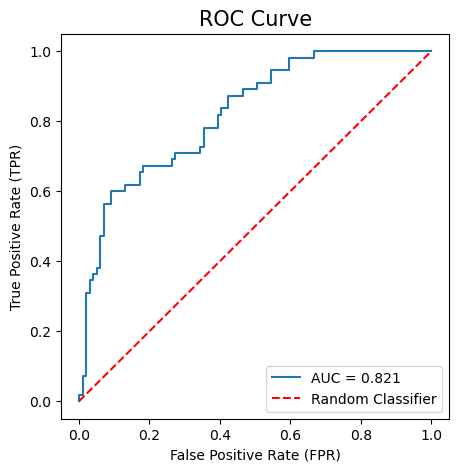

In [24]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC - AUC Score:", roc_auc)
plot_roc(y_test, y_prob)

### Coefficient Interpretation

Positive coefficients indicate that an increase in the feature increases the probability of diabetes, while negative coefficients indicate a decrease in the probability. Features with larger absolute coefficient values have a greater influence on the prediction.

In [25]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":model.coef_[0]
})
coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.553753
5,BMI,0.101800
0,Pregnancies,0.067602
1,Glucose,0.037338
7,Age,0.034611
3,SkinThickness,0.007710
4,Insulin,-0.001669
2,BloodPressure,-0.013234


### Conclusion
A Logistic Regression model was successfully developed to predict diabetes. The model was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC Score, and the ROC Curve. These metrics indicate how effectively the model classifies diabetic and non-diabetic patients.

### Streamlit

In [26]:
from pickle import dump

In [27]:
dump(model, open('model.pkl', 'wb'))

In [28]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable


### STREAMLIT DEPLOYMENT
The Logistic Regression model has been deployed using Streamlit to provide an interactive web application for diabetes prediction.

**Features of the application:**
- Loads the trained Logistic Regression model (`model.pkl`).
- Accepts user inputs for:
  - Pregnancies
  - Glucose
  - Blood Pressure
  - Skin Thickness
  - Insulin
  - BMI
  - Diabetes Pedigree Function
  - Age
- Predicts whether the patient is **Diabetic** or **Not Diabetic**.
- Displays the prediction through an interactive user interface.

**GitHub Repository:**
https://github.com/sandhya-143
    
**Streamlit Deployment:
**https://diabetes-prediction-logisticregression.streamlit.app/

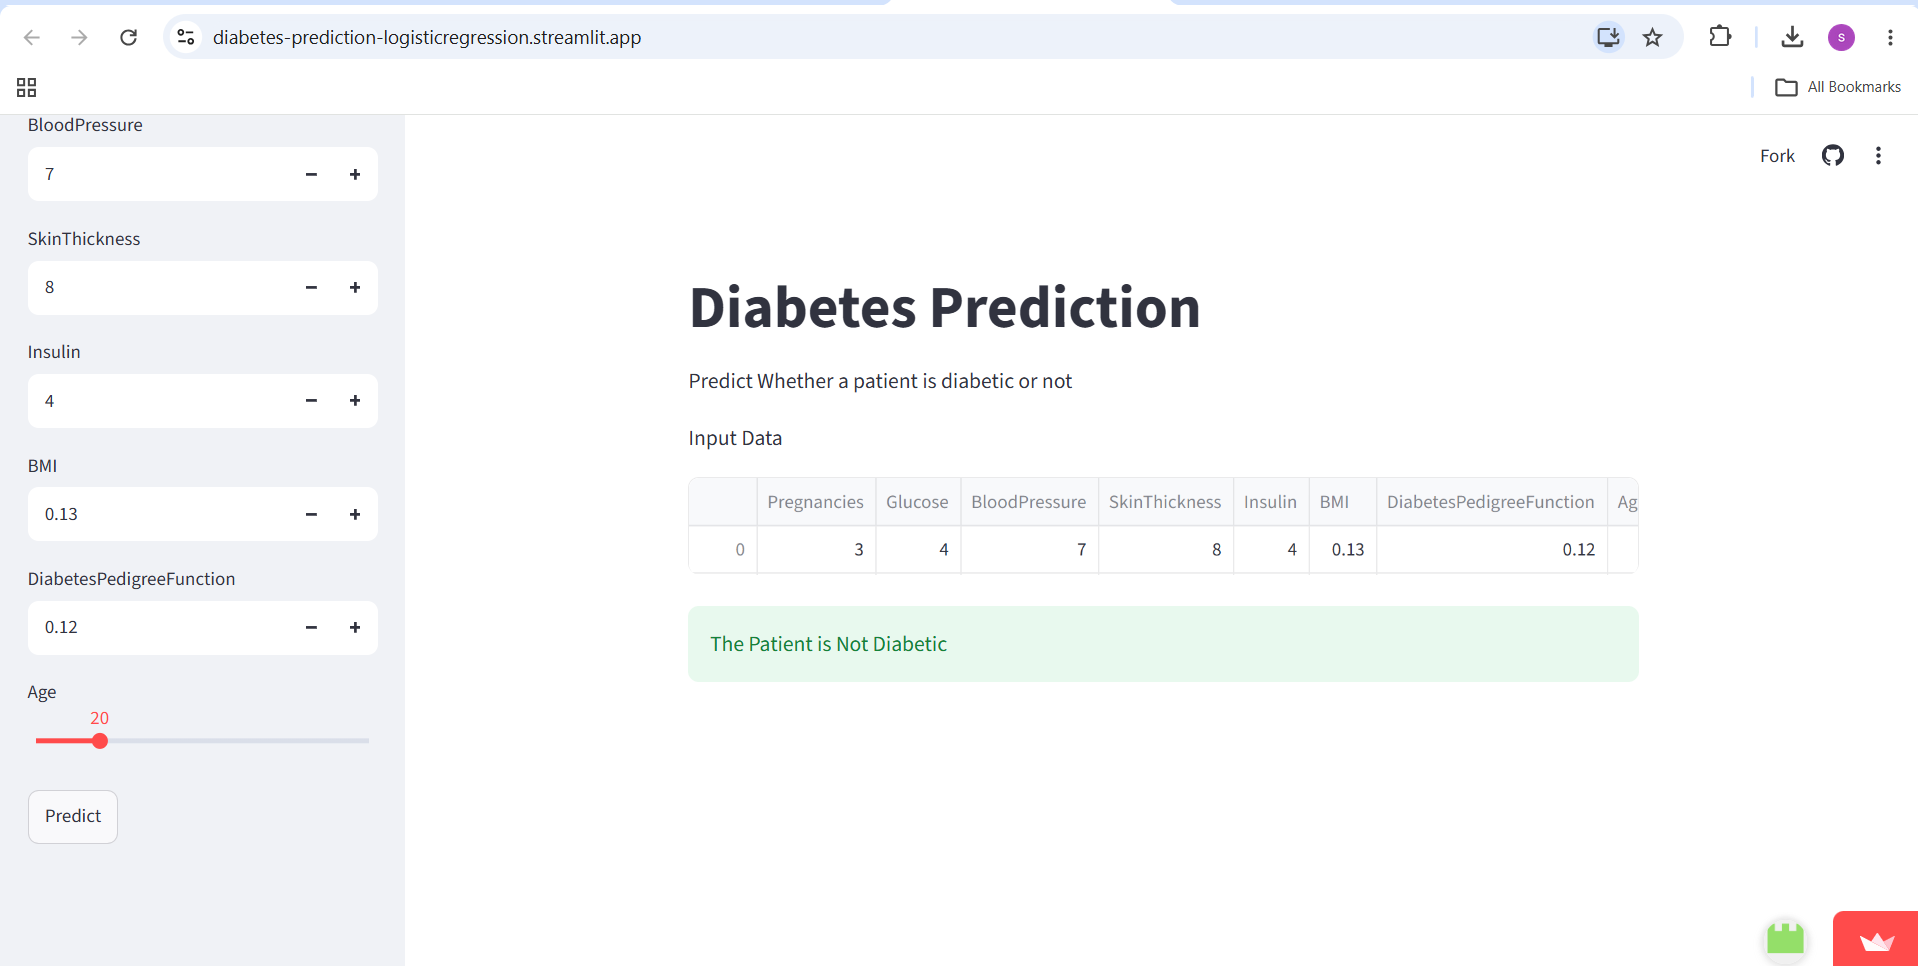

### INTERVIEW QUESTIONS

### 1. What is the difference between precision and recall?
Precision --> Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. It measures how accurate the positive predictions are.
Recall --> Recall is the ratio of correctly predicted positive observations to all actual positive observations. It measures the model's ability to identify all positive cases.

1. Precision is important when the cost of false positives is high.
2. Recall is important when the cost of false negatives is high.


#### FORMULA:
##### PRECISION = TP/(TP + FP)
##### RECALL = TP/(TP + FN)

### 2. What is Cross-Validation, and why is it important in binary classification?
Cross-validation is a model evaluation technique in which the dataset is divided into multiple subsets (folds). The model is trained on some folds and tested on the remaining fold. This process is repeated until each fold has been used as the test set once.

##### Importance in Binary Classification:

1. Provides a more reliable estimate of model performance.
2. Helps detect overfitting and underfitting.
3. Ensures the model generalizes well to unseen data.
4. Makes efficient use of the available dataset.
5. Improves the robustness and stability of the model evaluation.
